In [89]:
import numpy as np
import healpy as hp
from matplotlib import pyplot as plt
import pysm3
import pysm3.units as u
import pymaster as nmt
%matplotlib inline
#import packages

Using PySM3 to simulate foreground and cmb maps. The noise is simulated as a random process and linked to the noise sensitivity of Planck

In [90]:
#simulating foregroud emission and noise at the different Planck frequencies
def simulate_planck_maps(nsides):
    """
    Simulate foreground emission and noise at different Planck frequencies.
    
    Parameters:
    nside (int): Healpix resolution parameter.
    
    Returns:
    tuple: Numpy arrays of simulated maps for noise, dust, synchrotron, free-free, and CMB components.
    """
    freqs = np.array([28.4,  44.1,  70.4,  100.0,  143.0,  217.0,  353.0 ])#545.0,  857.0
    
    sens = np.array([150.,  162.,  210.,  77.4,  33.,  46.8, 154,  42.,  5016.])
    
    # Initialize PySM sky models for different foregrounds and CMB
    sky_d = pysm3.Sky(nside=nsides, preset_strings=["d1"])
    sky_s = pysm3.Sky(nside=nsides, preset_strings=["s1"])
    sky_f = pysm3.Sky(nside=nsides, preset_strings=["f1"])
    sky_cmb = pysm3.Sky(nside=nsides, preset_strings=["c1"])
    
       # Initialize storage for maps
    noise_pl, dust_pl, sync_pl, ff_pl, cmb_pl = [], [], [], [], []
    
    for nf, freq in enumerate(freqs):
        # Generate noise
        noise = np.random.normal(size=(12 * nsides**2)) * sens[nf] / hp.nside2resol(nsides, True)
        noise_pl.append(noise)
        
        # Convert emissions to uK_CMB
        conversion = u.K_RJ.to(u.K_CMB, equivalencies=u.cmb_equivalencies(freq * u.GHz))
        
        dust_pl.append(sky_d.get_emission(freq * u.GHz)[0] * conversion)
        sync_pl.append(sky_s.get_emission(freq * u.GHz)[0] * conversion)
        ff_pl.append(sky_f.get_emission(freq * u.GHz)[0] * conversion)
        cmb_pl.append(sky_cmb.get_emission(freq * u.GHz)[0] * conversion)
    
    # Convert lists to numpy arrays (N_freq, N_pixels)
    return  np.array(noise_pl), np.array(dust_pl), np.array(sync_pl), np.array(ff_pl), np.array(cmb_pl)


In [91]:
nside=128
npix = hp.nside2npix(nside)
freqs = np.array([28.4,  44.1,  70.4,  100.0,  143.0,  217.0,  353.0]) #,  545.0,  857.0
n_freqs = len(freqs)

In [92]:
noise, dust, sync, ff, cmb = simulate_planck_maps(nside)

Combining the CMB and foreground maps to be input into ILC

In [93]:
maps_pl = cmb + noise + dust + sync + ff #cmb and foregrounds combined
fgds_pl= dust + sync + ff #combined foregrounds
print(maps_pl.shape)

(7, 196608)


Transforimng frequency maps to harmonic space by decomposition

In [94]:
#transform maps to spherical harmonics
lmax=3*nside -1 #default is lmax= 3*nside+1
almsize=hp.Alm.getsize(lmax)
print(almsize)
print((lmax+1)**2)
print(lmax)
alm_maps=np.zeros((n_freqs, almsize), dtype=complex) #storing coefficients in an array of dim n_freqs*almsize. dtype is complex to account for -ive values

for nf in range(n_freqs):
    alm_maps[nf,:]= hp.map2alm(maps_pl[nf,:], lmax=lmax, mmax=None, iter=0, pol=False) #record alm corresponding to each f for a corresponding l and m
    

73920
147456
383


Compute nf x nf Covariance matrix by fixing l for particular $a_{lm}$. Compute weights for every l
$$
\hat{C}_{l}^{ij} = \frac{1}{2l+1}\sum_{m=-l}^{+l} a_{lm}^{i}a^{j \dagger }_{lm}
$$

In [95]:
def compute_cl(almmaps:np.ndarray, l_max: int, n_freq: int)-> tuple[np.ndarray, np.ndarray]:
    r"""
    Compute the power spectrum C_l from alm_maps.

    The power spectrum is computed as:

    \[ \hat{C}_{l}^{ij} = \frac{1}{2l+1}\sum_{m=-l}^{+l} a_{lm}^{i}a^{j \dagger }_{lm} \]
    
    Parameters:
    ----------
    almmaps : np.ndarray
        Array of shape (n_freq, num_alm) containing spherical harmonic coefficients.
    
    l_max : int
        Maximum multipole lmax.
    
    n_freq : int
        Number of frequency channels.
    
    Returns:
    -------
    alm_p : np.ndarray
        Truncated spherical harmonic values for m>0.
    
    C_l : np.ndarray
        Power spectrum array of shape (lmax+1, n_freq, n_freq).
    """
    Cl = np.zeros((l_max + 1, n_freq, n_freq), dtype=float)
    
    for l in range(l_max + 1):
        index = np.zeros((l + 1), dtype=int)
        
        for m in range(l + 1):
            index[m] = hp.Alm.getidx(l_max, l, m)  # Get Alm index
        
        almp = almmaps[:, index]  # Extract relevant alm values
        
        # Compute C_l
        Cl[l, :, :] = np.real(np.outer(almp[:, 0], almp[:, 0]))
        
        for m in range(1, l + 1):  # Sum over m
            Cl[l, :, :] += 2 * np.real(np.outer(almp[:, m], np.conj(almp[:, m])))
    
    return almp, Cl

In [96]:
alm_p, C_l=compute_cl(alm_maps, lmax, n_freqs)
print(alm_p.shape)
print(C_l.shape)

(7, 384)
(384, 7, 7)


In [97]:
gal_cut = np.radians(10) #galactic latitutde of 10 degrees
cut = np.zeros(npix, dtype=np.float64)
cut[hp.query_strip(nside, np.pi/2-gal_cut, np.pi/2+gal_cut)] = 1 #10 degrees above and below the galactic plane

mask = np.clip(hp.smoothing(cut, fwhm=np.radians(10)), 0, None) #apodizing

print(cut.shape)

(196608,)


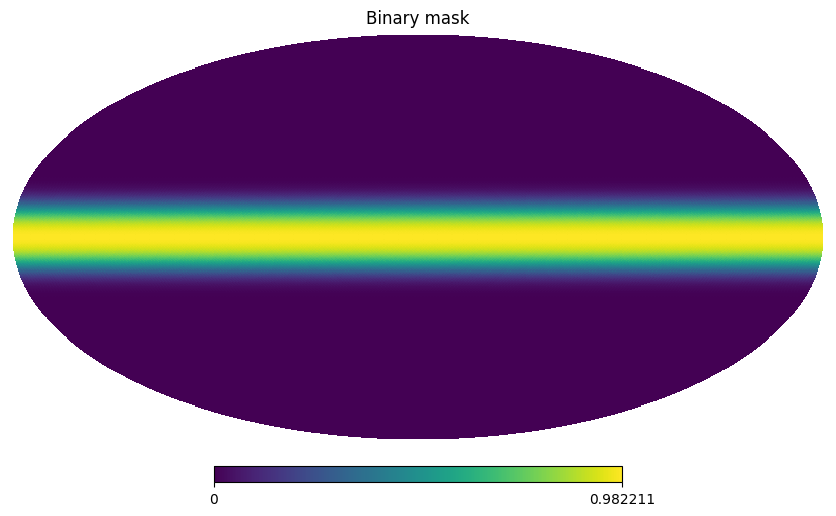

In [98]:
hp.mollview(mask, title="Binary mask")

In [99]:
def compute_decoupled_cl( maps: np.ndarray, masks:np.ndarray, nsides:int, l_max:int, n_freq:int)-> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Compute the power spectra using NaMaster for a set of frequency maps.

    Parameters:
    - maps: numpy array of shape (n_freqs, n_maps) containing the frequency maps
    - masks: mask to apply to the maps
    - nsides: resolution parameter for the maps
    - l_max: maximum multipole for the power spectra
    - n_freq: number of frequency channels

    Returns:
    - p_cl: raw power spectrum (coupled)
    - matrix: mode coupling matrix
    - cldec: decoupled power spectrum
    """
    p_cl =np.zeros((l_max+1, n_freq, n_freq))
    cldec = np.zeros((l_max+1, n_freq, n_freq))
    

    # Loop over all pairs of frequency maps (cross-power spectra)
    for i in range(n_freq):
        for j in range(i, n_freq):  # Compute only upper triangle (symmetric matrix)

            # Define the masked fields for the two maps
            f_i = nmt.NmtField(1 - masks, [maps[i, :]]) 
            f_j = nmt.NmtField(1 - masks, [maps[j, :]]) 

            # Compute the coupled power spectrum for (i, j)
            p_cl[:, i, j] = nmt.compute_coupled_cell(f_i, f_j)
            


            # Define a NaMaster binning scheme (no binning)
            b = nmt.NmtBin.from_nside_linear(nsides, 1)

            # Create NaMaster workspace and get the coupling matrix
            w = nmt.NmtWorkspace.from_fields(f_i, f_j, b)
            #w = nmt.NmtWorkspace()
            w.compute_coupling_matrix(f_i, f_j, b)
        
            #w.compute(f_i, f_j, b)
            matrix = w.get_coupling_matrix() #lxl

            # Compute the inverse of the mode-coupling matrix
            matrix_inv = np.linalg.pinv(matrix, rcond=1e-6)

            # Compute the decoupled power spectrum using Einstein summation
            cldec[:, i, j] = np.einsum('ij,j->i', matrix_inv, p_cl[:, i, j])

            # Since Cl is symmetric, copy the value to (j, i)
            if i != j:
                cldec[:, j, i] = cldec[:, i, j]
                p_cl[:, j, i] = p_cl[:, i, j]
    return p_cl, matrix, cldec

Computing the decoupled power spectrum of the masked CMB map

In [100]:
pcl_cmb, mcm_cmb, cmb_dec= compute_decoupled_cl(cmb, mask, nside, lmax, n_freqs)


In [101]:
Cl_cmb = hp.anafast(cmb[0]) #input cmb map

In [102]:
pcl, mcm, cl_dec =compute_decoupled_cl(maps_pl, mask, nside, lmax, n_freqs)
print(pcl.shape)
print(mcm.shape)
print(cl_dec.shape)

(384, 7, 7)
(384, 384)
(384, 7, 7)


(384,)


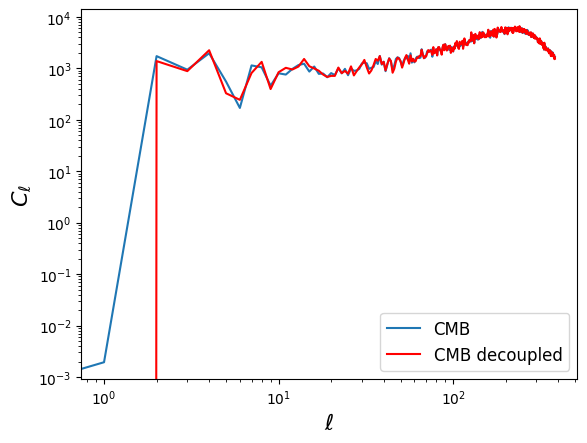

In [103]:
ells =np.arange(lmax+1)
print(ells.shape)
norm= (ells*(ells+1))/(2*np.pi)

plt.plot(ells, norm*Cl_cmb, label='CMB')
plt.plot(ells, norm*cmb_dec[:,0,0], 'r-',label= 'CMB decoupled')
#plt.plot(ells, norm*cl_dec[:,0,0], 'g-',label= 'Decoupled Cl')
plt.xlabel('$\\ell$', fontsize=16)
plt.ylabel('$C_\\ell$', fontsize=16)
plt.xscale("log")
plt.yscale("log")
plt.legend(fontsize=12)
plt.show()

Mode Coupling Matrix

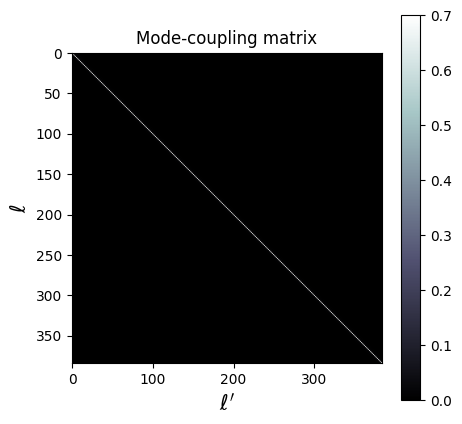

In [104]:
# Plot MCM
plt.figure(figsize=(5, 5))
plt.title('Mode-coupling matrix')
plt.imshow(mcm, cmap='bone')
#plt.plot(mcm[:,30])
plt.ylabel("$\\ell$", fontsize=15)
plt.xlabel("$\\ell'$", fontsize=15)
plt.colorbar()
plt.show()


Now we can compute the inverse covariance matrix and compute the weights using $$\omega_i(l) = \frac{\sum_j (C_l^{-1})_{ij} b_{j}}{\sum_{ij}b_i (C_l^{-1})_{ij} b_{j}}$$

where $b_i $ represents the CMB transfer function. $b_i = [1,...,1]$

In [105]:
def compute_weights(n_freqs:int, l_max=int, Cl= np.ndarray)-> tuple[np.ndarray, np.ndarray]:

    r"""
    Computes the weights for the covariance matrix.

    \(\omega_i(l) = \frac{\sum_j (C_l^{-1})_{ij} b_{j}}{\sum_{ij}b_i (C_l^{-1})_{ij} b_{j}}\)

    Parameters:
    -------
    n_freqs: int
      Number of frequency channels.
    l_max: int
      Maximum number of multipole lmax.
    Cl: np.ndarray
      Covariance matrix.
    
    Returns:
    -------
      Cl_inv : np.ndarray
        Pseudo inverse of the Cl_matrix.
      
      wi : np.ndarray
        Weights dependent on frequency and multipole of shape (n_freqs x m) 
    """
    #CMB spectral energy density
    b= np.ones(n_freqs, dtype=float ) #array filled with values of 1. column vector

    wi= np.zeros((n_freqs, l_max+1), dtype=float) #weights

    Cl_inv =np.zeros((n_freqs, n_freqs), dtype=float)

    for l in range(l_max+1):

        Cl_matrix =   Cl[l,:,:]/(2*l +1) #cov matrix for a specific l (nfreqs x nfreqs)
        

        Cl_inv[:,:] = np.linalg.pinv(Cl_matrix[:,:]) #(nfreqs x nfreqs)
        numerator = np.dot(Cl_inv,  b) #nfreqs x 1
        b_trans = b.T
        denominator = np.dot(b_trans, np.dot( Cl_inv, b)) #scalar?? 1x1


        for nf in range(n_freqs):
            wi[:, l] = numerator[:]/denominator# (nfreqs x m) Since this is inside l loop it is only the weight for a specific l. looping will give us the correct shape?
            #w[:,l]= np.maximum(w[:,l], 0)  # Force weights to be non-negative
            wi[:,l] /= np.sum(wi[:,l], axis=0, keepdims=True)  # Normalize to sum to 1
    return Cl_inv, wi

(7, 7)
(7, 384)


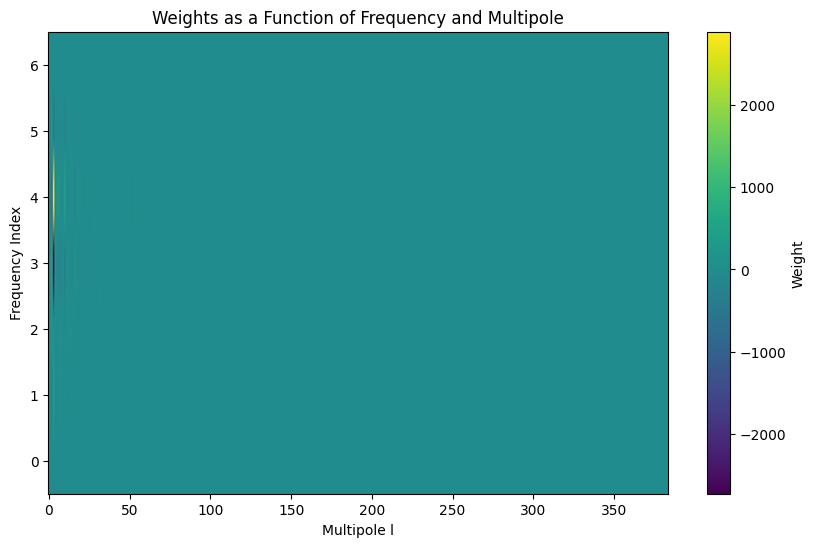

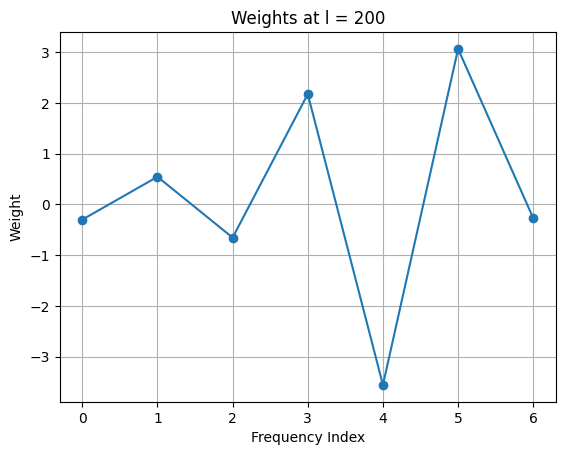

In [106]:
cl_inv, w = compute_weights(n_freqs, lmax, cl_dec)
print(cl_inv.shape)
print(w.shape) #nf x m array
#issue in dividing? values too small

plt.figure(figsize=(10, 6))
plt.imshow(w, aspect='auto', cmap='viridis', origin='lower')
plt.colorbar(label="Weight")
plt.xlabel("Multipole l")
plt.ylabel("Frequency Index")
plt.title("Weights as a Function of Frequency and Multipole")
plt.show()


plt.plot(range(n_freqs), w[:, 200], marker='o', linestyle='-')

plt.xlabel("Frequency Index")
plt.ylabel("Weight")
plt.title(f"Weights at l = {200}")
plt.grid()
plt.show()

Masking the input frequency masks

In [107]:
masked =np.zeros((n_freqs, npix))
alm_masked = np.zeros((n_freqs, almsize), dtype=complex)
for nf in range(n_freqs):
    masked[nf,:] =maps_pl[nf,:]*(1-mask)
    alm_masked[nf,:]= hp.map2alm(masked[nf,:], lmax=lmax, mmax=None, iter=0, pol=False)

Sum over frequencies to get $a_{ILC}$ for every l weighted sum across all frequencies for each m to get a cleaned spherical harmonic coefficient alm for each m at a given l.

$$a^{ILC}_{lm} = \sum_i w_i(l)a^i_{lm}$$

In [108]:
def compute_alm_ilc(almmaps:np.ndarray, alm_size:int, wi:np.ndarray, l_max:int):
    r"""
    Computes the weighted spherical harmonic coefficients.

    \(a^{ILC}_{lm} = \sum_i w_i(l)a^i_{lm}\)

    Parameters:
    -------
    almmaps: np.ndarray
        Sky maps converted from pixel space to harmonic space.
    
    alm_size: int
        Number of spherical harmonic coefficients (lmax+1)^2.

    wi : np.ndarray
        Weights.

    l_max: int
        Maximum multipole.
    
    Returns:
    ------
    almilc : np.ndarray
        Shape of (almsize x 1)
    """

    almilc = np.zeros((alm_size), dtype=complex)

    for l in range(l_max +1):
        index= np.zeros((l+1), dtype=int)
        for m in range(l+1):
            index[m]= hp.Alm.getidx(l_max, l, m)
        alm_p = almmaps[:, index]

        alm = np.dot(wi[:,l], alm_p[:,:]) # multiplying (9x384) and (9x1) to get (384x1)=this is for one l (m =0-> l). we iterate over all l
        '''
        #summing over frequencies. and taking ALL m values for a fixed l. Looping over l means 
        so we get an alm weighted by contributions from all frequencies over all scales.
        this should be the same as writing alm_p??
        '''
        almilc[index]= alm #putting alm values back into an array corresponding to their proper positions. flat array
    return almilc

In [109]:
alm_ilc=compute_alm_ilc(alm_masked, almsize, w, lmax)
print(alm_ilc.shape)

(73920,)


Converting back to pixel space

In [110]:
maps_out = hp.alm2map(alm_ilc, nside, lmax=lmax, mmax=None)
print(maps_out.shape)

(196608,)


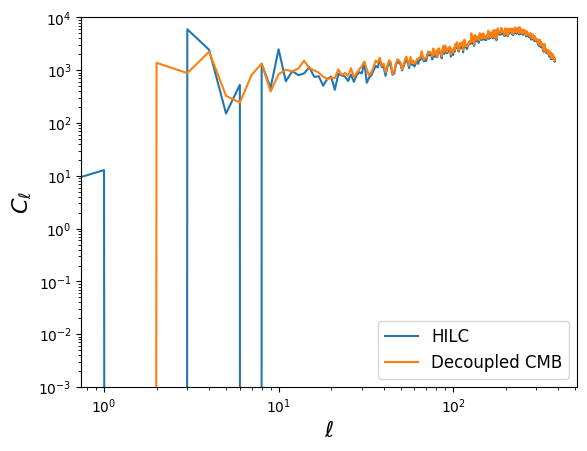

In [111]:

#pcl_hilc, mcm_hilc, cl_hilc =compute_decoupled_cl_2(maps_out, mask, nside, lmax, n_freqs)
f_hilc = nmt.NmtField(1-mask, [maps_out])
pcl_hilc = nmt.compute_coupled_cell(f_hilc, f_hilc)
b = nmt.NmtBin.from_nside_linear(nside, 1)
w_hilc=nmt.NmtWorkspace.from_fields(f_hilc, f_hilc, b)
#w.compute_coupling_matrix(f_hilc,f_hilc,b)
mcm_hilc=w_hilc.get_coupling_matrix()
mcm_hilc_inv = np.linalg.inv(mcm_hilc)
cl_hilc =np.dot(mcm_hilc_inv, pcl_hilc[0])
hilc =hp.anafast(maps_out)

#plt.plot(ells, (norm*cl_dec[:,5,3]), label='Decoupled Cl')
plt.plot(ells, norm*cl_hilc, label='HILC')
plt.plot(ells, norm*cmb_dec[:,0,0], label='Decoupled CMB')
#plt.plot(ells, norm*hilc, 'r-',label= 'biased hilc')
plt.xlabel('$\\ell$', fontsize=16)
plt.ylabel('$C_\\ell$', fontsize=16)
plt.xscale("log")
plt.yscale("log")
plt.ylim(1e-3,1e+4)
plt.legend(fontsize=12)
plt.show()

Compute the fractional difference between the two spectra:

$$
\text{frac\_diff}(\ell) = \frac{C_{\ell}^{\text{Decoupled}} - C_{\ell}^{\text{Input}}}{C_{\ell}^{\text{Input}}}
$$


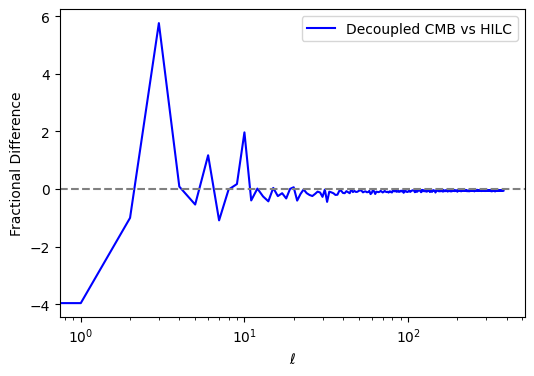

In [112]:
#frac_diff = (cmb_dec - Cl_cmb) / Cl_cmb  # Avoid division by zero
diff = (cl_hilc - cmb_dec[:,0,0]) / cmb_dec [:,0,0]

plt.figure(figsize=(6, 4))
#plt.plot(ells, frac_diff, label="input CMB vs Decoupled CMB", color="black")
plt.plot(ells, diff, label="Decoupled CMB vs HILC", color="blue")
plt.axhline(0, linestyle="--", color="gray")  # Reference line
#plt.yscale("log")
#plt.ylim(-2500, 500)
plt.xscale("log")
plt.xlabel(r"$\ell$")
plt.ylabel(r"Fractional Difference")
#plt.title("Fractional Difference")
plt.legend()
plt.show()

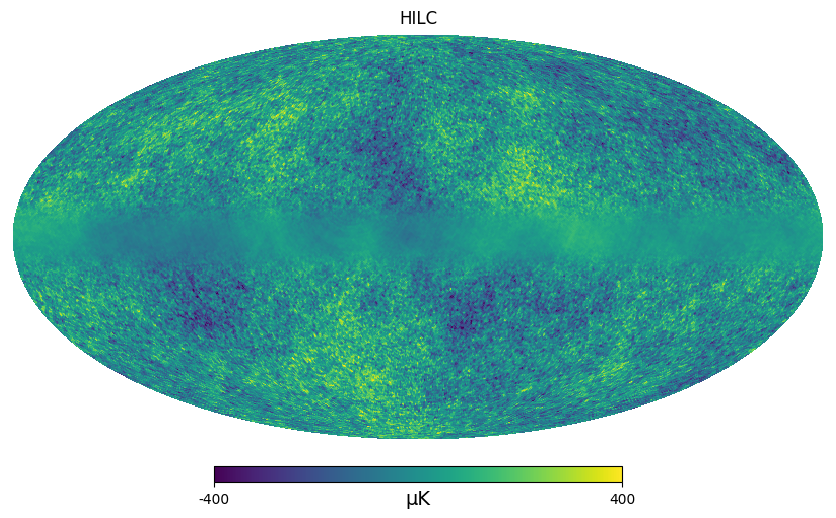

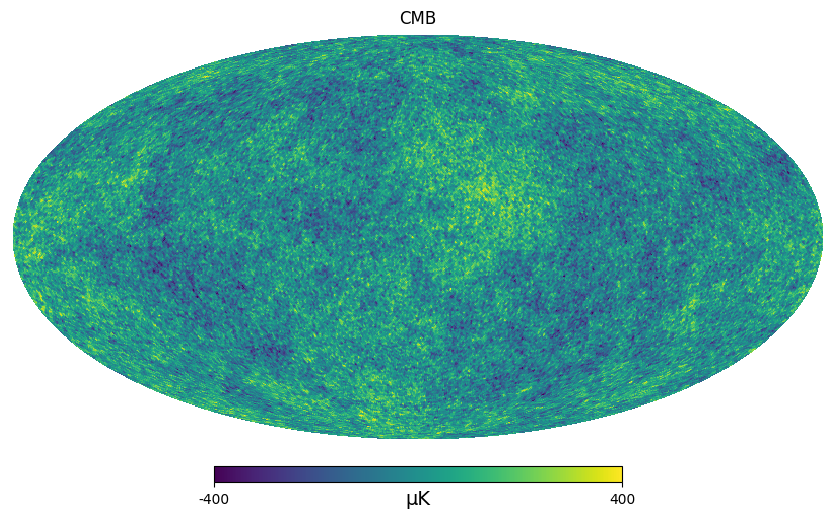

In [113]:
ilc =maps_out-np.mean(maps_out)
#hp.mollview(maps_out, title= "HILC masked", min=-400, max=400)
hp.mollview(ilc, title= "HILC", min=-400, max=400, unit="μK")
hp.mollview(cmb[0],title ="CMB", min=-400, max=400, unit="μK")
#hp.mollview(maps_pl[4], title="Original Map with Foregrounds", min=-400, max=400) #comparison to uncleaned


residual map=HILC map−Input CMB map

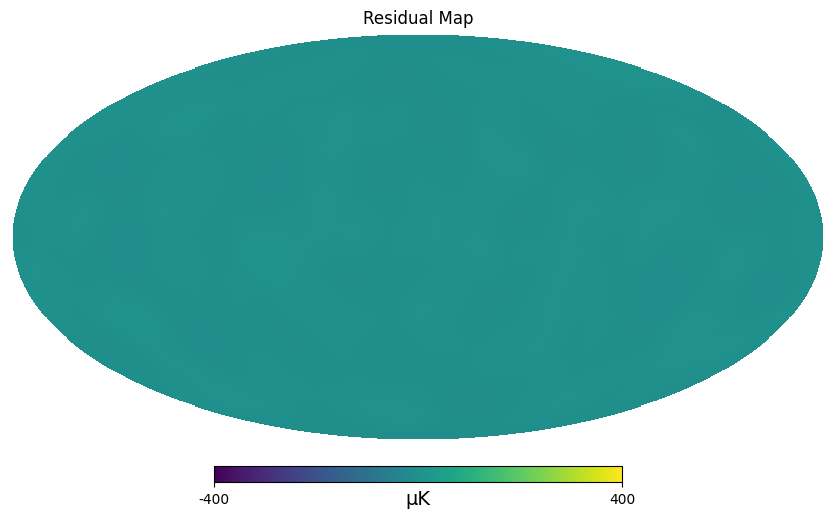

In [114]:
residual_map = hp.synfast(diff, nside=128, pol=False)#(ilc - (1-mask)*cmb_pl[0]  )

hp.mollview(residual_map, title="Residual Map", min=-400, cmap="viridis", max=400, unit="μK")
